<a href="https://colab.research.google.com/github/Optimus0205/Computer-Vision/blob/main/8_VGGNET_Architecture_%26_%20Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#VGGNET Architecture

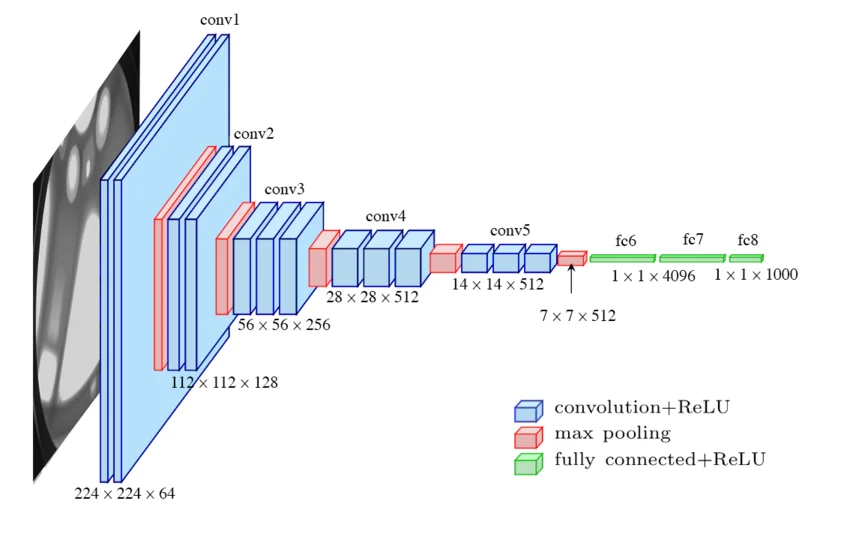



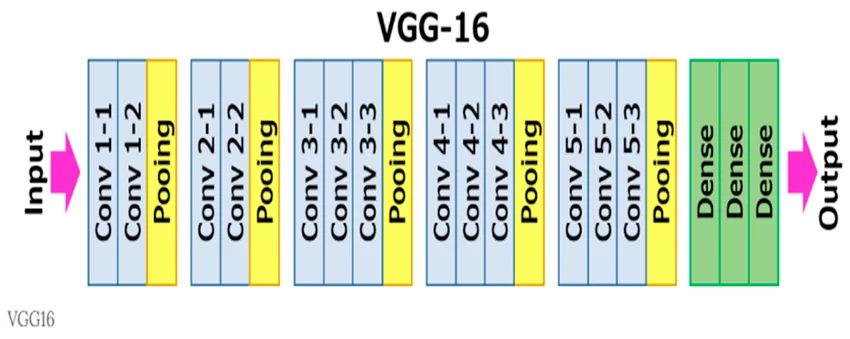

#VGG19
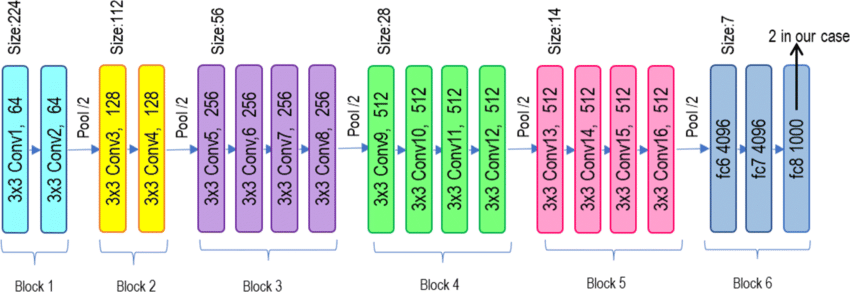

##Connecting to kaggle            
Chest X-Ray Dataset

In [1]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_d1069a861fbb67920c2bc2fa7ff6fed4"

In [2]:
!pip install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 18.7 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [3]:
!kaggle datasets download -d jtiptj/chest-xray-pneumoniacovid19tuberculosis

Dataset URL: https://www.kaggle.com/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis
License(s): other
100% 1.74G/1.74G [00:15<00:00, 124MB/s]



In [4]:
!unzip /content/chest-xray-pneumoniacovid19tuberculosis.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/NORMAL/NORMAL2-IM-0843-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0845-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0846-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0847-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0848-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0849-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0851-0001-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0851-0001-0002.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0851-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0852-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0853-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0854-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0855-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0856-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0857-0001.j

## Importing all the libraries

In [5]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.layers import Rescaling

# For reproducibility
import numpy as np
import random
import os

seed=123
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [6]:
# Directories containing the dataset
train_dir='/content/train/'
val_dir='/content/val/'
test_dir='/content/test/'

# Hyperparameters
img_width, img_height = 224,224
batch_size=32
epochs=20
num_classes=4

Can't perform validation split as all the data is not in the one directory

In [7]:
# Loading the data without validation split
train_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_width,img_height),
    batch_size=batch_size
)

Found 6326 files belonging to 4 classes.


In [8]:
validation_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(img_width,img_height),
    batch_size=batch_size
)

Found 38 files belonging to 4 classes.


In [9]:
test_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_width,img_height),
    batch_size=batch_size
)

Found 771 files belonging to 4 classes.


In [10]:
# Data Augmentation
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip('horizontal and vertical'),
    layers.RandomRotation(0.2),
])

In [11]:
# Applying data augmentation only to the training dataset
train_dataset = train_dataset.map (lambda x,y: (data_augmentation(x, training=True), y))

In [12]:
# Prefetch the datasets for better performance
AUTOTUNE=tf.data.AUTOTUNE
train_dataset=train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset=validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset=test_dataset.prefetch(buffer_size=AUTOTUNE)

## Steps to folloe while building a CNN

Get the dataset.     
Data Analysis        
        
        


- Normalise the dataset        
- Use validation split        
- Initialise the generators with proper values.        
- Data Augmentation        
- Autotune and prefetch.        
- Model Building.        
- Model summary        
- Model compile        
- Model training        
- Model evaluation on train, test, validation        
- Performance plots and metrics.        
- Model save

In [13]:
def build_vgg16(input_shape=(224,224,3),num_classes=4):
  model=models.Sequential()

  # Add input layer
  model.add(layers.Input(shape=input_shape))

  # Normalization Layer
  model.add(Rescaling(1./255))

  # Block1
  model.add(layers.Conv2D(64,(3,3), padding='same', activation='relu'))
  model.add(layers.Conv2D(64,(3,3), padding='same', activation='relu'))
  model.add(layers.MaxPooling2D((2,2)))        #   MaxPooling2D(2,2) by default uses pool_size=(2,2) and strides=(2,2)

  # Block2
  model.add(layers.Conv2D(128,(3,3), padding='same', activation='relu'))
  model.add(layers.Conv2D(128,(3,3), padding='same', activation='relu'))
  model.add(layers.MaxPooling2D((2,2)))        #   MaxPooling2D(2,2) by default uses pool_size=(2,2) and strides=(2,2)

  # Block3
  model.add(layers.Conv2D(256,(3,3), padding='same', activation='relu'))
  model.add(layers.Conv2D(256,(3,3), padding='same', activation='relu'))
  model.add(layers.Conv2D(256,(3,3), padding='same', activation='relu'))
  model.add(layers.MaxPooling2D((2,2)))        #   MaxPooling2D(2,2) by default uses pool_size=(2,2) and strides=(2,2)

  # Block4
  model.add(layers.Conv2D(512,(3,3), padding='same', activation='relu'))
  model.add(layers.Conv2D(512,(3,3), padding='same', activation='relu'))
  model.add(layers.Conv2D(512,(3,3), padding='same', activation='relu'))
  model.add(layers.MaxPooling2D((2,2)))        #   MaxPooling2D(2,2) by default uses pool_size=(2,2) and strides=(2,2)

  # Block5
  model.add(layers.Conv2D(512,(3,3), padding='same', activation='relu'))
  model.add(layers.Conv2D(512,(3,3), padding='same', activation='relu'))
  model.add(layers.Conv2D(512,(3,3), padding='same', activation='relu'))
  model.add(layers.MaxPooling2D((2,2)))        #   MaxPooling2D(2,2) by default uses pool_size=(2,2) and strides=(2,2)

  # Flattening
  model.add(layers.Flatten())

  # Fully Connected Layers
  model.add(layers.Dense(4096, activation='relu'))
  model.add(layers.Dropout(0.5))
  model.add(layers.Dense(4096, activation='relu'))
  model.add(layers.Dropout(0.5))
  model.add(layers.Dense(num_classes,activation='softmax'))

  return model

In [14]:
model=build_vgg16(num_classes=num_classes)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │        16,38

 Total params: 134,276,932 (512.23 MB)

 Trainable params: 134,276,932 (512.23 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',     # Use categorical_crossentropy if labels are one-hot encoded
              metrics=['accuracy'])

In [16]:
history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs
)

Epoch 1/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 204s 798ms/step - accuracy: 0.6002 - loss: 1.1235 - val_accuracy: 0.2105 - val_loss: 1.8538
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 102s 512ms/step - accuracy: 0.6126 - loss: 1.0603 - val_accuracy: 0.2105 - val_loss: 1.8204
Epoch 3/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 101s 510ms/step - accuracy: 0.6126 - loss: 1.0602 - val_accuracy: 0.2105 - val_loss: 1.8511
Epoch 4/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 103s 520ms/step - accuracy: 0.6126 - loss: 1.0600 - val_accuracy: 0.2105 - val_loss: 1.8182
Epoch 5/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 101s 510ms/step - accuracy: 0.6126 - loss: 1.0611 - val_accuracy: 0.2105 - val_loss: 1.8060
Epoch 6/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 105s 529ms/step - accuracy: 0.6126 - loss: 1.0592 - val_accuracy: 0.2105 - val_loss: 1.8199
Epoch 7/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 140s 521ms/step - accuracy: 0.6126 - loss: 1.0584 - val_accuracy: 0.2105 - val_loss: 1.8067
Epoch 8/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 103s 518ms/step - accuracy: 0.6126 -

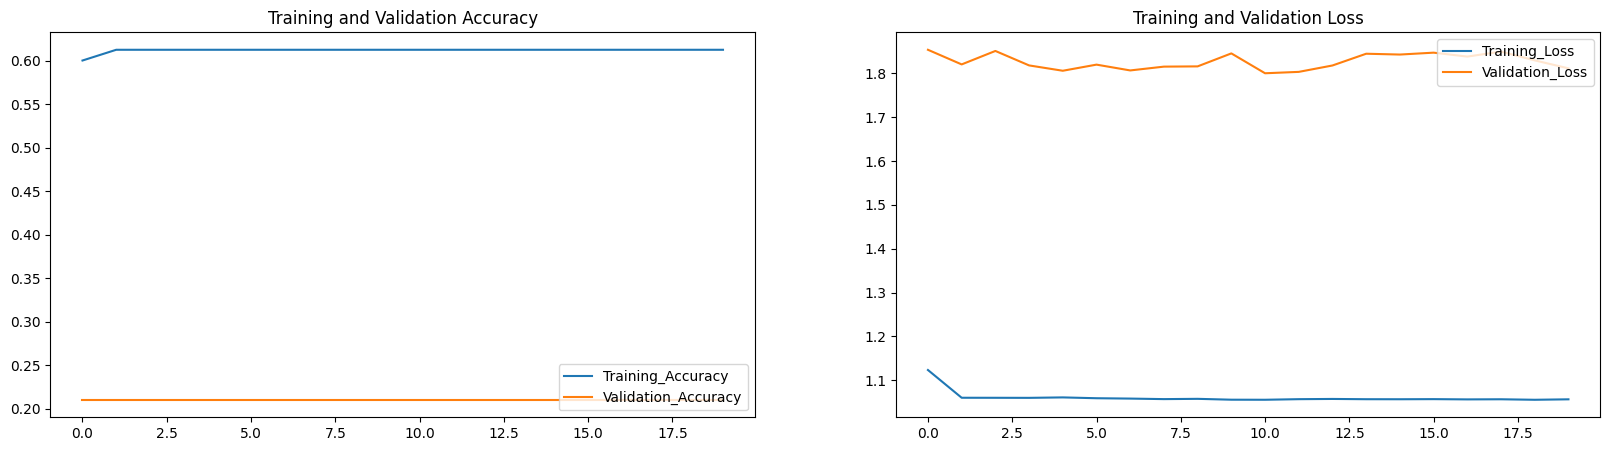

In [17]:
import matplotlib.pyplot as plt

acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range=range(len(acc))

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label='Training_Accuracy')
plt.plot(epochs_range,val_acc,label='Validation_Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,loss,label='Training_Loss')
plt.plot(epochs_range,val_loss,label='Validation_Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [18]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 392ms/step - accuracy: 0.5058 - loss: 1.2009
Test Accuracy: 50.58%


In [19]:
# Train set prediction
y_train_true=np.concatenate([y for x, y in train_dataset], axis=0)
y_train_pred=model.predict(train_dataset)
y_train_pred=np.argmax(y_train_pred,axis=1)

#Validation Set prediction
y_val_true=np.concatenate([y for x, y in validation_dataset], axis=0)
y_val_pred=model.predict(validation_dataset)
y_val_pred=np.argmax(y_val_pred,axis=1)

#Test Set prediction
y_test_true=np.concatenate([y for x, y in test_dataset], axis=0)
y_test_pred=model.predict(test_dataset)
y_test_pred=np.argmax(y_test_pred,axis=1)

198/198 ━━━━━━━━━━━━━━━━━━━━ 83s 409ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 452ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 263ms/step


In [20]:
from matplotlib import cm
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm_train=confusion_matrix(y_train_true,y_train_pred)
cm_val=confusion_matrix(y_val_true,y_val_pred)
cm_test=confusion_matrix(y_test_true,y_test_pred)

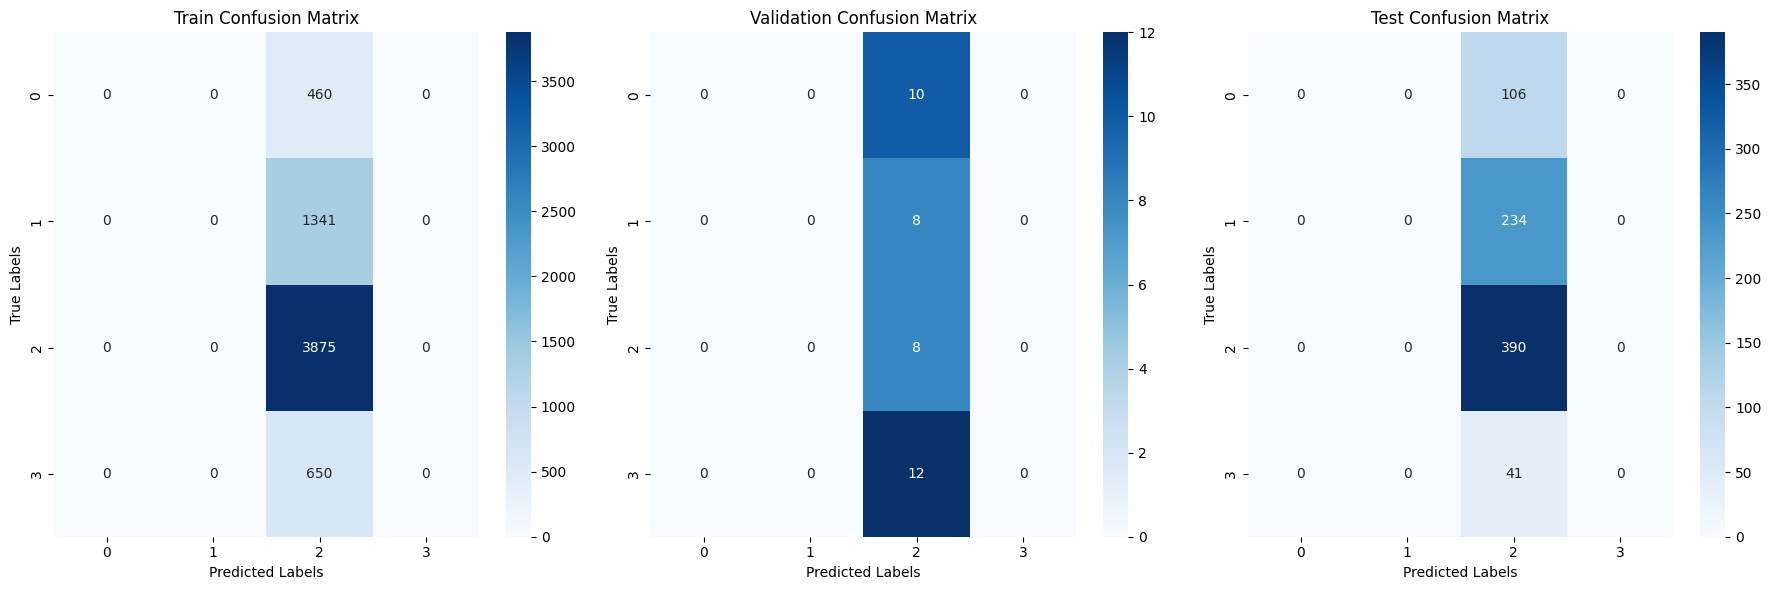

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up the figure
fig,axes=plt.subplots(1,3, figsize=(18,6))

#Train Confusion Matrix
sns.heatmap(cm_train,annot=True,fmt='d',cmap='Blues',ax=axes[0])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

#Validation Confusion Matrix
sns.heatmap(cm_val,annot=True,fmt='d',cmap='Blues',ax=axes[1])
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

#Test Confusion Matrix
sns.heatmap(cm_test,annot=True,fmt='d',cmap='Blues',ax=axes[2])
axes[2].set_title('Test Confusion Matrix')
axes[2].set_xlabel('Predicted Labels')
axes[2].set_ylabel('True Labels')

#Adjust Layout
plt.tight_layout()
plt.show()

## Very bad results
- simplest model made
- can improve no. of epochs


## Transfer Learning

### Transfer Learning with fixed weight in convolutions and training model on FC(fully connected) layers or Dense layers

In [22]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Input

In [23]:
# Inbuit VGG16 in keras rather than building from scratch

base_model=VGG16(weights=None,
                 include_top=False,
                 input_tensor=Input(shape=(img_width,img_height,3)))
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Loading VGG16 with pretrained ImageNet weights, excluding top fully connected layers
base_model=VGG16(weights='imagenet',
                 include_top=False,
                 input_tensor=Input(shape=(img_width,img_height,3)))
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Freeze the layers in the base model
for layer in base_model.layers:
    layer.trainable=False

In [28]:
# Building the model
model=models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

In [29]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',                  # Use categorical_crossentropy if labels are one-hot encoded
              metrics=['accuracy'])

In [31]:
history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 65s 325ms/step - accuracy: 0.9379 - loss: 0.2264 - val_accuracy: 0.7895 - val_loss: 0.8887
Epoch 2/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 68s 342ms/step - accuracy: 0.9428 - loss: 0.1984 - val_accuracy: 0.9474 - val_loss: 0.0701
Epoch 3/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 83s 347ms/step - accuracy: 0.9456 - loss: 0.2023 - val_accuracy: 0.9211 - val_loss: 0.2942
Epoch 4/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 87s 375ms/step - accuracy: 0.9494 - loss: 0.1785 - val_accuracy: 0.9737 - val_loss: 0.2150
Epoch 5/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 72s 326ms/step - accuracy: 0.9538 - loss: 0.1548 - val_accuracy: 0.8421 - val_loss: 0.4735
Epoch 6/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 93s 465ms/step - accuracy: 0.9537 - loss: 0.1521 - val_accuracy: 0.9474 - val_loss: 0.0980
Epoch 7/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 138s 447ms/step - accuracy: 0.9559 - loss: 0.1574 - val_accuracy: 0.9211 - val_loss: 0.2670
Epoch 8/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 134s 408ms/step - accuracy: 0.9567 - loss:

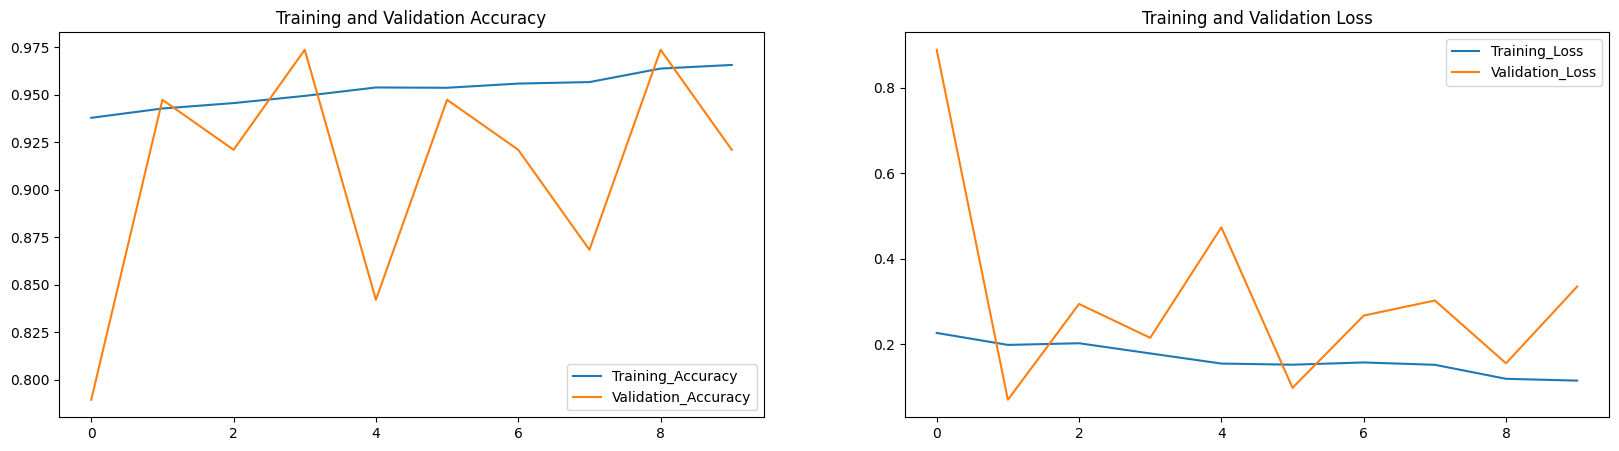

In [32]:
import matplotlib.pyplot as plt

acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range=range(len(acc))

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label='Training_Accuracy')
plt.plot(epochs_range,val_acc,label='Validation_Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,loss,label='Training_Loss')
plt.plot(epochs_range,val_loss,label='Validation_Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [33]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 437ms/step - accuracy: 0.8093 - loss: 0.9506
Test Accuracy: 80.93%


In [34]:
# Train set prediction
y_train_true=np.concatenate([y for x, y in train_dataset], axis=0)
y_train_pred=model.predict(train_dataset)
y_train_pred=np.argmax(y_train_pred,axis=1)

#Validation Set prediction
y_val_true=np.concatenate([y for x, y in validation_dataset], axis=0)
y_val_pred=model.predict(validation_dataset)
y_val_pred=np.argmax(y_val_pred,axis=1)

#Test Set prediction
y_test_true=np.concatenate([y for x, y in test_dataset], axis=0)
y_test_pred=model.predict(test_dataset)
y_test_pred=np.argmax(y_test_pred,axis=1)

198/198 ━━━━━━━━━━━━━━━━━━━━ 73s 362ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 451ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 289ms/step


In [35]:
from matplotlib import cm
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm_train=confusion_matrix(y_train_true,y_train_pred)
cm_val=confusion_matrix(y_val_true,y_val_pred)
cm_test=confusion_matrix(y_test_true,y_test_pred)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up the figure
fig,axes=plt.subplots(1,3, figsize=(18,6))

#Train Confusion Matrix
sns.heatmap(cm_train,annot=True,fmt='d',cmap='Blues',ax=axes[0])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

#Validation Confusion Matrix
sns.heatmap(cm_val,annot=True,fmt='d',cmap='Blues',ax=axes[1])
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

#Test Confusion Matrix
sns.heatmap(cm_test,annot=True,fmt='d',cmap='Blues',ax=axes[2])
axes[2].set_title('Test Confusion Matrix')
axes[2].set_xlabel('Predicted Labels')
axes[2].set_ylabel('True Labels')

#Adjust Layout
plt.tight_layout()
plt.show()

## For more Fine Tuning

In [38]:
# load VGG16 with pre-trained ImageNet weights,excluding the top (fuuly connected layers)
base_model=VGG16(weights='imagenet',
                 include_top=False,
                 input_tensor=Input(shape=(img_width,img_height,3)))

# Freeze the first few layers
for layer in base_model.layers[:13]:
  layer.trainable=False

# Unfreee the remaining layers
for layer in base_model.layers[13:]:
  layer.trainable=True

In [39]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 9,439,232 (36.01 MB)

 Non-trainable params: 5,275,456 (20.12 MB)

In [41]:
base_model1=VGG16(weights='imagenet',
                 include_top=True,
                 input_tensor=Input(shape=(img_width,img_height,3)))
base_model2=VGG16(weights='imagenet',
                 include_top=False,
                 input_tensor=Input(shape=(img_width,img_height,3)))
base_model1.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
base_model2.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)